# Full cost / efficiency analysis

Token, dollar, and wall-clock cost per config on the `full` run set, read from
`eval/results/full/cost.json`. Two questions: (1) what does each config cost to run,
and (2) where does the spend go by role. Means carry SEM error bars (n = 25 papers).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_SET = "full"

# Walk up until we find eval/ so the notebook runs regardless of CWD.
ROOT = Path.cwd()
while not (ROOT / "eval").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "eval" / "results" / RUN_SET
BATCHES = ROOT / "eval" / "batches.json"
FIG_DIR = ROOT / "eval" / "analysis" / "figures" / RUN_SET
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- palette (seaborn deep quad) ---
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MODEL_COLORS = {"A": PALETTE[0], "B": PALETTE[1], "C": PALETTE[2]}
MODEL_NAMES = {"A": "qwen3-32b", "B": "mistral-small-3.2", "C": "llama-3.3-70b"}
ROLE_COLORS = dict(zip(
    ("leader", "clarity", "experiments", "impact"), PALETTE
))
ROLES = ("leader", "clarity", "experiments", "impact")
C_HET, C_REF = PALETTE[0], PALETTE[1]  # blue het, orange ref
C_ANNOT, C_MUTED, C_REF_LINE, C_EDGE, C_ERR = (
    "#333333", "#555555", "#666666", "#FFFFFF", "#333333",
)
# --- layout constants (fixed legend gap from figure bottom) ---
LEGEND_Y = 0.035          # figure coords — same on every plot
MARGIN_NO_LEGEND = 0.12
MARGIN_LEGEND = 0.22      # barh / scatter with legend, no rotated x
MARGIN_XROT30 = 0.28
MARGIN_XROT45 = 0.32
MARGIN_HEATMAP = 0.28
SAVE_PAD = 0.12


def legend_bottom(*, xrot=0, titled=False):
    if xrot >= 40:
        b = MARGIN_XROT45
    elif xrot >= 20:
        b = MARGIN_XROT30
    else:
        b = MARGIN_LEGEND
    if titled:
        b += 0.04
    return b


def legend_below(
    fig, ax=None, *, handles=None, labels=None, ncol=2, title=None, xrot=0,
):
    """Figure-level legend at fixed LEGEND_Y. Returns bottom margin for save_fig."""
    if handles is None:
        if ax is None:
            raise ValueError("legend_below needs ax or explicit handles")
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        handles, labels = ax.get_legend_handles_labels()
    kw = dict(
        loc="lower center", bbox_to_anchor=(0.5, LEGEND_Y), ncol=ncol,
        fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
    )
    if title:
        kw["title"] = title
    fig.legend(handles, labels, **kw)
    return legend_bottom(xrot=xrot, titled=title is not None)


def annotate_configs(ax, x, y, configs, *, fontsize=7, offsets_by_name=None):
    """Config slug near each scatter point."""
    defaults = [
        (7, 5), (7, -7), (-7, 5), (-7, -7),
        (10, 0), (-10, 0), (0, 9), (0, -9),
    ]
    for i, (xi, yi, name) in enumerate(zip(x, y, configs)):
        dx, dy = (offsets_by_name or {}).get(name, defaults[i % len(defaults)])
        ax.annotate(
            name, (xi, yi), textcoords="offset points", xytext=(dx, dy),
            fontsize=fontsize, color=C_ANNOT,
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
        )


def pad_axes_for_labels(ax, *, xfrac=0.06, yfrac=0.08):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0 - (x1 - x0) * xfrac, x1 + (x1 - x0) * xfrac)
    ax.set_ylim(y0 - (y1 - y0) * yfrac, y1 + (y1 - y0) * yfrac)


def save_fig(fig, path, *, bottom=MARGIN_NO_LEGEND, top=0.90, left=None, right=None):
    kw = dict(bottom=bottom, top=top)
    if left is not None:
        kw["left"] = left
    if right is not None:
        kw["right"] = right
    fig.subplots_adjust(**kw)
    fig.savefig(path, bbox_inches="tight", pad_inches=SAVE_PAD)


LEGEND_KW = dict(
    loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
    fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
)

FIG_RANK, FIG_COMPACT = (8.5, 4.5), (6, 3.6)
FIG_SCATTER, FIG_PANEL, FIG_WIDE = (7, 5), (9.5, 3.8), (12, 4.0)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.alpha": 0.25, "grid.color": "#E0E0E0", "grid.linestyle": "-",
    "lines.linewidth": 1.5, "patch.linewidth": 0.5,
})


def fig_title(desc: str, *, n_papers: int | None = None, extra: str = "") -> str:
    """Notebook title — keep light; LaTeX captions carry detail."""
    parts = []
    if RUN_SET == "pilot":
        parts.append("pilot")
    if n_papers is not None and (RUN_SET == "pilot" or n_papers != 25):
        parts.append(f"n={n_papers} papers")
    if extra:
        parts.append(extra)
    return f"{desc} ({', '.join(parts)})" if parts else desc


batch = json.loads(BATCHES.read_text())[RUN_SET]
pool = batch["pool"]
slug_to_letter = {v: k for k, v in pool.items()}


def letter(value: str) -> str:
    if value in pool:
        return value
    return slug_to_letter.get(value, value)


def tuple_letters(cfg: str) -> tuple[str, ...]:
    m = batch["configs"][cfg]
    return tuple(letter(m[r]) for r in ROLES)


def is_homogeneous(cfg: str) -> bool:
    return len(set(tuple_letters(cfg))) == 1


RESULTS = RESULTS_DIR / "cost.json"
cost = json.loads(RESULTS.read_text())

per_config = cost["per_config"]
order = [c for c in batch["configs"] if c in per_config]  # batch order

def stat(cfg, field):
    s = per_config[cfg][field]
    return s["mean"], s["sem"]

rows = []
for c in order:
    t = tuple_letters(c)
    cm, cs = stat(c, "cost_usd")
    im, isem = stat(c, "input_tokens")
    om, osem = stat(c, "output_tokens")
    tm, tsem = stat(c, "time_s")
    rows.append({
        "config": c, "tuple": ",".join(t), "homogeneous": is_homogeneous(c),
        "cost_usd": cm, "cost_sem": cs,
        "input_tokens": im, "input_sem": isem,
        "output_tokens": om, "output_sem": osem,
        "time_s": tm, "time_sem": tsem,
    })

df = pd.DataFrame(rows)
if "missing_price_models" in cost and cost["missing_price_models"]:
    print("WARNING missing prices for:", cost["missing_price_models"])
print(f"run-set : {RUN_SET}")
print(f"configs : {len(df)}")
print(f"n papers: {int(per_config[order[0]]['cost_usd']['n'])}")
df[["config", "tuple", "cost_usd", "input_tokens", "output_tokens", "time_s"]].round(4)

run-set : full
configs : 7
n papers: 25


,config,tuple,cost_usd,input_tokens,output_tokens,time_s
0,All-A,"A,A,A,A",0.0217,117057.60,9234.76,440.2103
1,All-B,"B,B,B,B",0.0072,62668.64,5293.60,82.3506
2,All-C,"C,C,C,C",0.0028,23714.84,1344.96,100.1055
3,specialist,"A,B,A,C",0.0156,99065.12,5776.88,285.8939
4,swap_experiments,"B,B,A,B",0.0101,71830.84,7528.80,168.3523
5,rot_2,"B,C,A,B",0.0176,140802.08,8976.64,219.3590
6,swap_leader,"A,B,B,B",0.0131,94016.44,4309.48,196.6465


## 1. Cost per review (USD)

Mean cost per paper-review with SEM error bars. Homogeneous references in grey,
heterogeneous in blue — the question is whether mixing models buys quality at a cost
premium or discount.

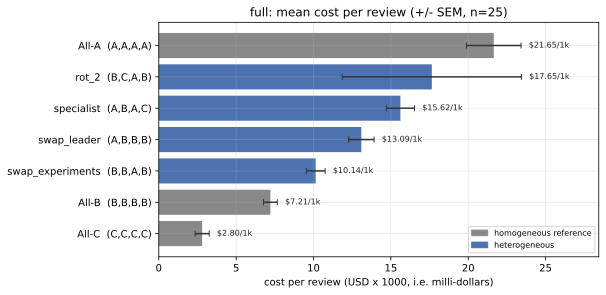

In [6]:
d = df.sort_values("cost_usd")
colors = [C_REF if h else C_HET for h in d["homogeneous"]]
labels = d["config"].tolist()

bar_y = np.arange(len(d))
fig, ax = plt.subplots(figsize=FIG_RANK)
ax.barh(
    bar_y,
    d["cost_usd"] * 1000,
    xerr=d["cost_sem"] * 1000,
    color=colors,
    error_kw={"ecolor": C_ERR, "capsize": 3},
)
for yi, (v, e) in enumerate(zip(d["cost_usd"].values, d["cost_sem"].values)):
    xpos = (v + e) * 1000 + 0.5
    ax.text(xpos, yi, f"${v*1000:.2f}/1k", va="center", fontsize=8, color=C_ANNOT)
x_right = max((v + e) * 1000 for v, e in zip(d["cost_usd"].values, d["cost_sem"].values)) + 5
ax.set_xlim(right=x_right)
ax.set_yticks(bar_y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_ylim(-0.5, len(d) - 0.5)
ax.set_xlabel("cost per review (USD x 1000, i.e. milli-dollars)")
ax.set_title(fig_title("Mean cost per review"))
bottom = legend_below(fig, handles=[
    plt.Rectangle((0, 0), 1, 1, color=C_REF),
    plt.Rectangle((0, 0), 1, 1, color=C_HET),
], labels=["homogeneous", "heterogeneous"], ncol=2)
save_fig(fig, FIG_DIR / "cost_per_review.png", bottom=bottom)
plt.show()


## 2. Where the spend goes — per-role breakdown

Stacked mean cost per role (`leader` includes its orchestration calls). Reveals whether a
config is expensive because of one heavy seat or uniformly.

/var/folders/hc/xcxqtp9n6pl665jf8bb5860r0000gn/T/ipykernel_66896/1838637540.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(rdf.index, rotation=30, ha="right")


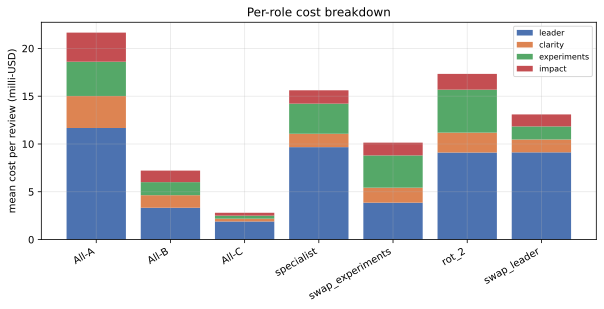

,leader,clarity,experiments,impact,total
config,,,,,
All-A,11.673,3.344,3.590,3.045,21.652
All-B,3.328,1.313,1.367,1.207,7.214
All-C,1.889,0.298,0.316,0.299,2.802
specialist,9.668,1.401,3.151,1.397,15.616
swap_experiments,3.860,1.567,3.375,1.338,10.140
rot_2,9.105,2.082,4.496,1.650,17.333
swap_leader,9.125,1.345,1.367,1.256,13.092


In [7]:
role_rows = []
for c in order:
    by_role = per_config[c]["by_role"]
    rec = {"config": c}
    for r in ROLES:
        rec[r] = by_role.get(r, {}).get("cost_usd", {}).get("mean", 0.0) * 1000
    role_rows.append(rec)

rdf = pd.DataFrame(role_rows).set_index("config").reindex(order)

fig, ax = plt.subplots(figsize=FIG_RANK)
bottom_arr = np.zeros(len(rdf))
for r in ROLES:
    ax.bar(rdf.index, rdf[r], bottom=bottom_arr, label=r, color=ROLE_COLORS[r])
    bottom_arr += rdf[r].values
ax.set_xticks(range(len(rdf)))
ax.set_ylabel("mean cost per review (milli-USD)")
ax.set_title(fig_title("Per-role cost breakdown"))
ax.set_xticklabels(rdf.index, rotation=30, ha="right")
bottom = legend_below(fig, ax, ncol=4, xrot=30)
save_fig(fig, FIG_DIR / "cost_by_role.png", bottom=bottom)
plt.show()

display((rdf.round(3)).assign(total=rdf.sum(axis=1).round(3)))


## 3. Tokens and latency

Input/output token mix and wall-clock time per review. Output tokens are the pricier half
and a proxy for review verbosity; time matters for throughput when scaling the pipeline.

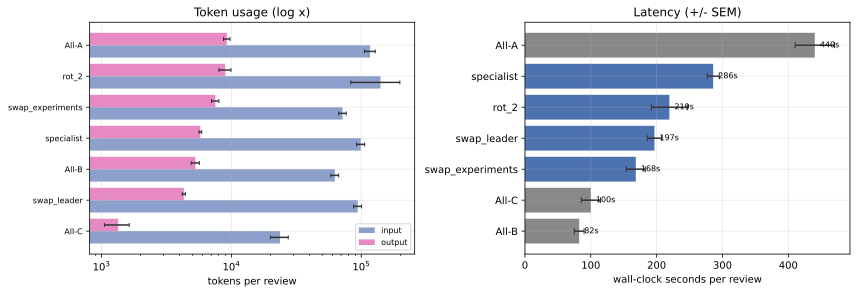

In [8]:
from matplotlib.patches import Patch

d = df.sort_values("output_tokens")
bar_y = np.arange(len(d))
fig, ax = plt.subplots(figsize=FIG_RANK)
ax.barh(bar_y - 0.2, d["input_tokens"], 0.4, xerr=d["input_sem"],
        label="input", color=C_HET, error_kw={"ecolor": C_ERR, "capsize": 2})
ax.barh(bar_y + 0.2, d["output_tokens"], 0.4, xerr=d["output_sem"],
        label="output", color=ROLE_COLORS["clarity"], error_kw={"ecolor": C_ERR, "capsize": 2})
ax.set_yticks(bar_y)
ax.set_yticklabels(d["config"], fontsize=8)
ax.set_xlim(left=1e3)
ax.set_xlabel("tokens per review")
ax.set_xscale("log")
ax.set_title(fig_title("Token usage"))
bottom = legend_below(fig, ax, ncol=2)
save_fig(fig, FIG_DIR / "cost_tokens.png", bottom=bottom)
plt.show()

d2 = df.sort_values("time_s")
colors = [C_REF if h else C_HET for h in d2["homogeneous"]]
bar_y2 = np.arange(len(d2))
fig, ax = plt.subplots(figsize=FIG_RANK)
ax.barh(bar_y2, d2["time_s"], xerr=d2["time_sem"],
        color=colors, error_kw={"ecolor": C_ERR, "capsize": 3})
ax.set_yticks(bar_y2)
ax.set_yticklabels(d2["config"], fontsize=8)
for yi, (v, e) in enumerate(zip(d2["time_s"].values, d2["time_sem"].values)):
    ax.text(v + e + 8, yi, f"{v:.0f}s", va="center", fontsize=8, color=C_ANNOT)
x_right = max(v + e for v, e in zip(d2["time_s"].values, d2["time_sem"].values)) + 45
ax.set_xlim(right=x_right)
ax.set_ylim(-0.5, len(d2) - 0.5)
ax.set_xlabel("wall-clock seconds per review")
ax.set_title(fig_title("Latency"))
bottom = legend_below(fig, handles=[
    Patch(color=C_REF, label="homogeneous"),
    Patch(color=C_HET, label="heterogeneous"),
], labels=["homogeneous", "heterogeneous"], ncol=2)
save_fig(fig, FIG_DIR / "cost_latency.png", bottom=bottom)
plt.show()


## 4. Cost vs. quality (merge with win-rate when ready)

The decision-relevant view: pay more only if you win more. Loads `win_rate.json` if it
exists and plots cost against win-rate; otherwise just prints the cost table so this
notebook stays runnable while the judge job is in flight.

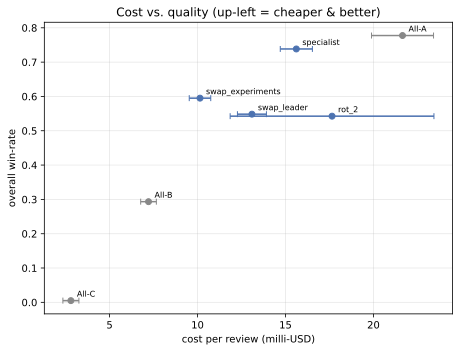

,config,tuple,cost_usd,win_rate
0,All-A,"A,A,A,A",0.0217,0.7775
3,specialist,"A,B,A,C",0.0156,0.7383
4,swap_experiments,"B,B,A,B",0.0101,0.5950
6,swap_leader,"A,B,B,B",0.0131,0.5483
5,rot_2,"B,C,A,B",0.0176,0.5425
1,All-B,"B,B,B,B",0.0072,0.2933
2,All-C,"C,C,C,C",0.0028,0.0050


In [10]:
wr_path = RESULTS_DIR / "win_rate.json"
if not wr_path.exists():
    print("win_rate.json not ready — showing cost ranking only.")
    display(df.sort_values("cost_usd")[["config", "tuple", "cost_usd", "time_s"]].round(4))
else:
    wr = json.loads(wr_path.read_text())
    plot_df = df.copy()
    plot_df["win_rate"] = plot_df["config"].map(lambda c: wr["per_config"].get(c, {}).get("overall", np.nan))

    fig, ax = plt.subplots(figsize=FIG_SCATTER)
    for _, r in plot_df.iterrows():
        col = C_REF if r["homogeneous"] else C_HET
        ax.errorbar(r["cost_usd"] * 1000, r["win_rate"], xerr=r["cost_sem"] * 1000,
                    fmt="o", color=col, capsize=3)
    ax.set_xlabel("cost per review (milli-USD)")
    ax.set_ylabel("overall win-rate")
    ax.set_title(fig_title("Cost vs. quality"))
    pad_axes_for_labels(ax)
    annotate_configs(ax, plot_df["cost_usd"] * 1000, plot_df["win_rate"], plot_df["config"])
    save_fig(fig, FIG_DIR / "cost_vs_winrate.png", bottom=MARGIN_NO_LEGEND)
    plt.show()
    display(plot_df[["config", "tuple", "cost_usd", "win_rate"]].sort_values("win_rate", ascending=False).round(4))
